In [40]:
# Import Data manipulation Libraries

import pandas as pd
import numpy as np

# Import Data Visualization Libraries

import seaborn as sns
import matplotlib.pyplot as plt

# import filter warnings library

import warnings
warnings.filterwarnings('ignore')

# import logging library

import logging
logging.basicConfig(filename = "model.log",
                    level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s')

In [41]:
# Load the dataset

url = 'https://raw.githubusercontent.com/adnansayyedd/CodeB_Internship/refs/heads/main/dataset_phishing.csv' 

df = pd.read_csv(url) 

df.sample(frac = 1) #shuffle dataset

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
1332,http://www.ijcte.org/papers/503-G1326.pdf,41,13,0,3,1,0,0,0,0,...,1,1,0,753,3995,872336,0,0,4,legitimate
10865,http://dropbox.progentrix.skyfencenet.com/,42,34,0,3,0,0,0,0,0,...,1,0,0,2216,2532,514430,0,1,0,phishing
1696,https://www.amazon.com/Best-Sellers-Computers-...,88,14,1,2,5,0,0,0,0,...,0,0,0,1559,9397,15,0,0,9,legitimate
6661,http://support-appleld.com.secureupdate.duilaw...,125,50,1,4,1,0,1,2,0,...,1,1,0,25,3992,5697976,0,1,0,phishing
4286,http://www.uniled.rs/memberservice/,35,13,0,2,0,0,0,0,0,...,1,0,0,119,-1,0,0,1,0,phishing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5721,http://tyrannisesprices.net/,28,20,0,1,0,0,0,0,0,...,1,0,0,343,388,0,0,1,0,phishing
11180,https://support-appleld.com.secureupdate.duila...,128,50,1,4,1,0,1,2,0,...,1,1,0,25,3993,5707171,0,1,0,phishing
5829,http://www.imxprs.com/free/webmaiil/accounttpo...,50,14,0,2,0,0,0,0,0,...,1,0,0,252,2305,541454,0,1,4,phishing
8215,https://www.432player.com/,26,17,0,2,0,0,0,0,0,...,1,1,0,140,2051,1872428,0,0,3,legitimate


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11430 entries, 0 to 11429
Data columns (total 89 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   url                         11430 non-null  object 
 1   length_url                  11430 non-null  int64  
 2   length_hostname             11430 non-null  int64  
 3   ip                          11430 non-null  int64  
 4   nb_dots                     11430 non-null  int64  
 5   nb_hyphens                  11430 non-null  int64  
 6   nb_at                       11430 non-null  int64  
 7   nb_qm                       11430 non-null  int64  
 8   nb_and                      11430 non-null  int64  
 9   nb_or                       11430 non-null  int64  
 10  nb_eq                       11430 non-null  int64  
 11  nb_underscore               11430 non-null  int64  
 12  nb_tilde                    11430 non-null  int64  
 13  nb_percent                  114

In [43]:
df.describe()

,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,...,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank
count,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.0,11430.000000,...,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,11430.000000,1.143000e+04,11430.000000,11430.000000,11430.000000
mean,61.126684,21.090289,0.150569,2.480752,0.997550,0.022222,0.141207,0.162292,0.0,0.293176,...,0.124759,0.775853,0.439545,0.072878,492.532196,4062.543745,8.567566e+05,0.020122,0.533946,3.185739
std,55.297318,10.777171,0.357644,1.369686,2.087087,0.155500,0.364456,0.821337,0.0,0.998317,...,0.330460,0.417038,0.496353,0.259948,814.769415,3107.784600,1.995606e+06,0.140425,0.498868,2.536955
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,-1.000000,-12.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,33.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,84.000000,972.250000,0.000000e+00,0.000000,0.000000,1.000000
50%,47.000000,19.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,0.000000,0.000000,242.000000,3993.000000,1.651000e+03,0.000000,1.000000,3.000000
75%,71.000000,24.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.000000,1.000000,1.000000,0.000000,449.000000,7026.750000,3.738455e+05,0.000000,1.000000,5.000000
max,1641.000000,214.000000,1.000000,24.000000,43.000000,4.000000,3.000000,19.000000,0.0,19.000000,...,1.000000,1.000000,1.000000,1.000000,29829.000000,12874.000000,1.076799e+07,1.000000,1.000000,10.000000


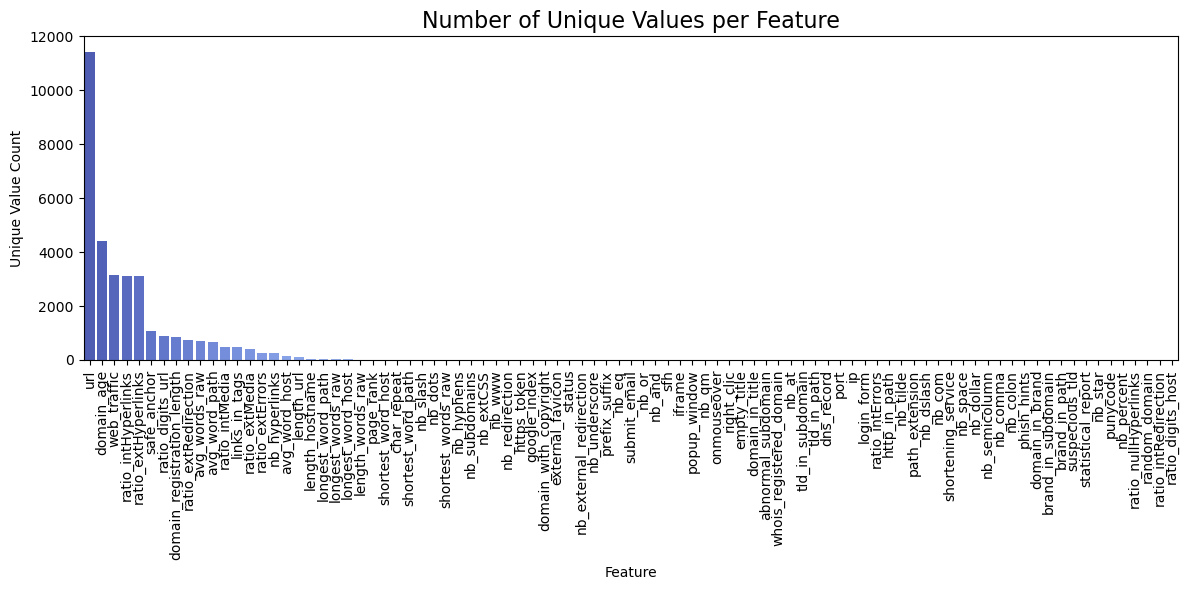

In [65]:
# Calculate number of unique values per column
nunique_values = df.nunique().sort_values(ascending=False)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=nunique_values.index, y=nunique_values.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Number of Unique Values per Feature', fontsize=16)
plt.ylabel('Unique Value Count')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

In [44]:
df.isnull().sum()

url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64

In [46]:
df['status'].value_counts()

status
legitimate    5715
phishing      5715
Name: count, dtype: int64

In [47]:
df['status'].nunique()

2

In [48]:
# Replacing URL with 0 and 1
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['url'] = le.fit_transform(df['url'])

df['url'].value_counts()

url
1065     2
4501     1
10779    1
1315     1
9201     1
        ..
6539     1
819      1
9629     1
5956     1
62       1
Name: count, Length: 11429, dtype: int64

In [49]:
# Replacing Value Status with 0 and 1

df['status'] = df['status'].replace({'legitimate': 0, 'phishing': 1})

df['status'].value_counts()

status
0    5715
1    5715
Name: count, dtype: int64

In [50]:
df['status'].value_counts()

status
0    5715
1    5715
Name: count, dtype: int64

In [60]:
df.corr()

,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
url,1.000000,-0.034605,-0.025093,NaN,0.035109,-0.019468,NaN,NaN,NaN,NaN,...,NaN,0.080432,NaN,0.058145,0.116118,0.085217,NaN,-0.277465,0.279492,-0.290971
length_url,-0.034605,1.000000,0.112491,NaN,0.358146,0.210383,NaN,NaN,NaN,NaN,...,NaN,0.037535,NaN,-0.037915,0.086448,-0.134648,NaN,0.294120,-0.059789,0.217898
length_hostname,-0.025093,0.112491,1.000000,NaN,0.181777,0.095697,NaN,NaN,NaN,NaN,...,NaN,0.033008,NaN,0.110503,0.072437,-0.026514,NaN,0.091124,-0.047698,0.105306
ip,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nb_dots,0.035109,0.358146,0.181777,NaN,1.000000,0.097916,NaN,NaN,NaN,NaN,...,NaN,0.071378,NaN,-0.050951,0.064936,-0.042126,NaN,0.153190,-0.072792,0.109748
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
web_traffic,0.085217,-0.134648,-0.026514,NaN,-0.042126,-0.055100,NaN,NaN,NaN,NaN,...,NaN,0.027118,NaN,-0.028432,-0.022756,1.000000,NaN,-0.189913,0.044760,-0.203653
dns_record,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
google_index,-0.277465,0.294120,0.091124,NaN,0.153190,0.175513,NaN,NaN,NaN,NaN,...,NaN,-0.143655,NaN,-0.116814,-0.210111,-0.189913,NaN,1.000000,-0.389887,0.731171
page_rank,0.279492,-0.059789,-0.047698,NaN,-0.072792,-0.075322,NaN,NaN,NaN,NaN,...,NaN,0.058843,NaN,0.245358,0.589602,0.044760,NaN,-0.389887,1.000000,-0.511137


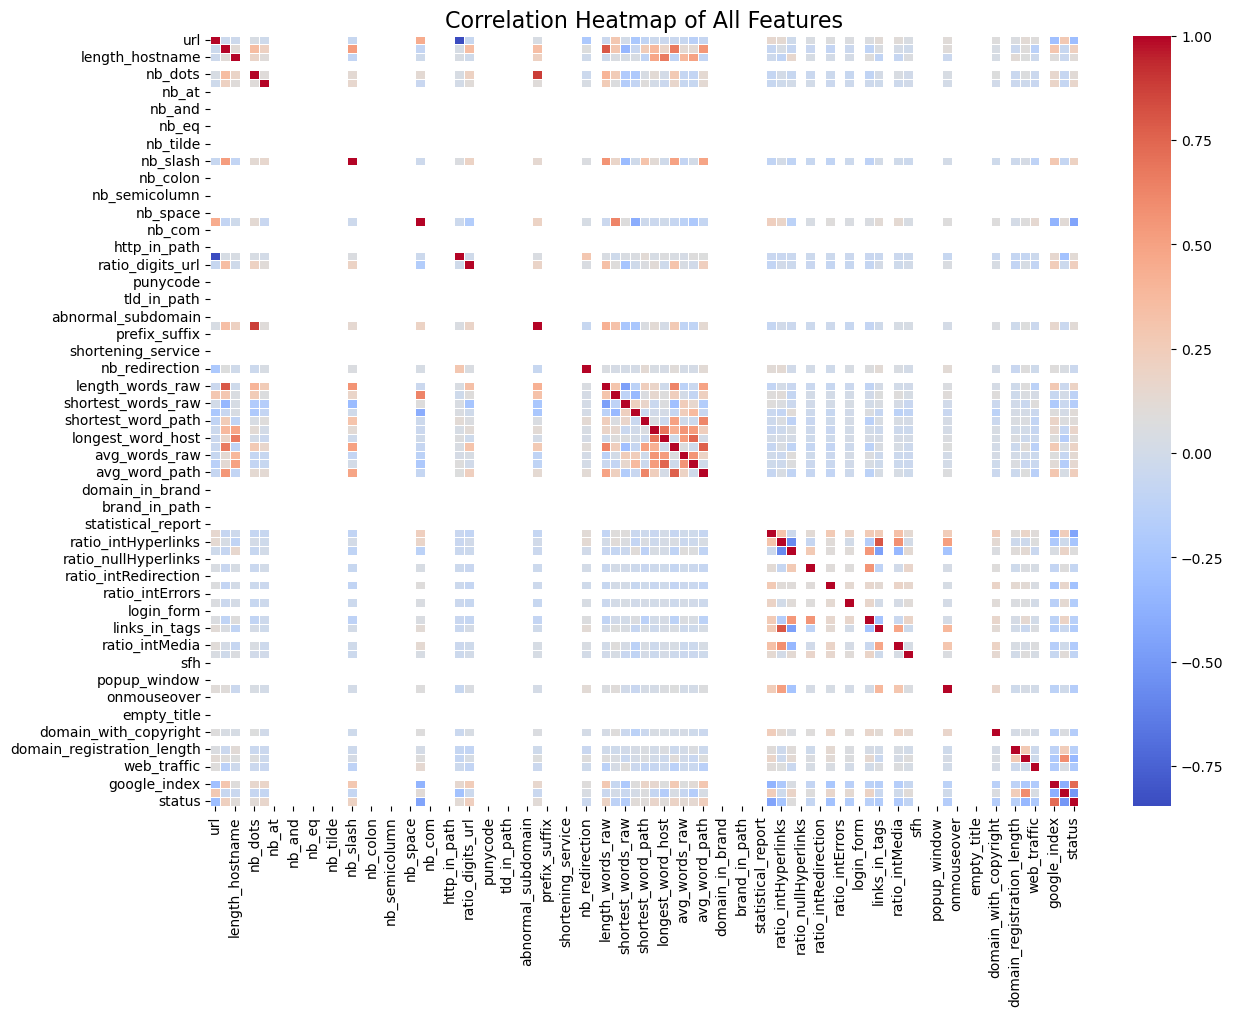

In [63]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.show()

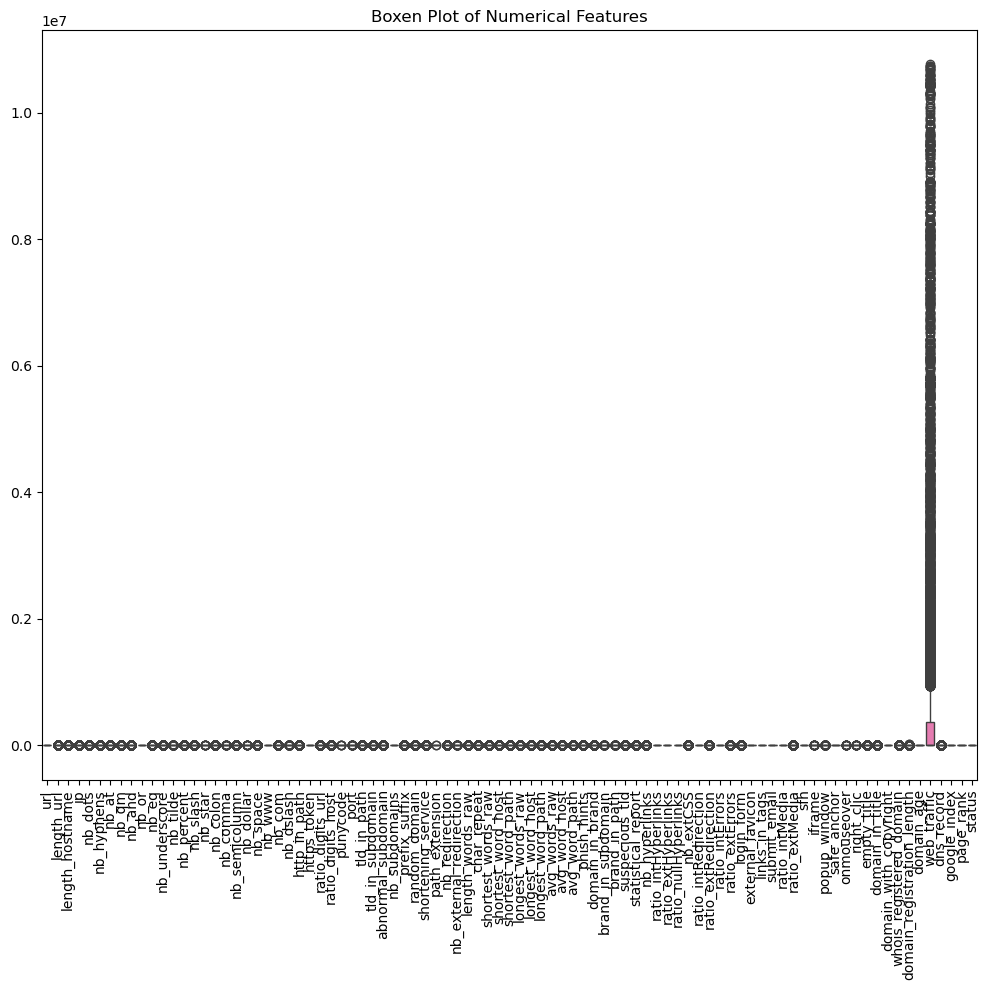

In [51]:
# Checking outliers 
plt.figure(figsize=(10, 10))
sns.boxplot(data= df)

plt.xticks(rotation = 90)  
plt.title("Boxen Plot of Numerical Features")
plt.tight_layout()

plt.show()

In [53]:
# Replace Outliers with Median Statergy

for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outliers.sum()

    if outlier_count > 0:
        replacement = df[col].median()  
        df.loc[outliers, col] = replacement
        print(f"Replaced {outlier_count} outliers in '{col}' with median.")
    else:
        print(f"No outliers found in '{col}'.")

No outliers found in 'url'.
Replaced 620 outliers in 'length_url' with median.
Replaced 775 outliers in 'length_hostname' with median.
Replaced 1721 outliers in 'ip' with median.
Replaced 567 outliers in 'nb_dots' with median.
Replaced 1371 outliers in 'nb_hyphens' with median.
Replaced 245 outliers in 'nb_at' with median.
Replaced 1555 outliers in 'nb_qm' with median.
Replaced 761 outliers in 'nb_and' with median.
No outliers found in 'nb_or'.
Replaced 1564 outliers in 'nb_eq' with median.
Replaced 1695 outliers in 'nb_underscore' with median.
Replaced 76 outliers in 'nb_tilde' with median.
Replaced 355 outliers in 'nb_percent' with median.
Replaced 401 outliers in 'nb_slash' with median.
Replaced 8 outliers in 'nb_star' with median.
Replaced 197 outliers in 'nb_colon' with median.
Replaced 24 outliers in 'nb_comma' with median.
Replaced 248 outliers in 'nb_semicolumn' with median.
Replaced 11 outliers in 'nb_dollar' with median.
Replaced 210 outliers in 'nb_space' with median.
No out

In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [55]:
# Checking VIF

def calculate_vif(dataset):
    vif = pd.DataFrame()
    vif['features'] = dataset.columns
    vif['VIF_Values'] = [variance_inflation_factor(dataset.values,i) for i in range(dataset.shape[1])]
    vif['VIF_Values'] = round(vif['VIF_Values'], 2)
    vif = vif.sort_values(by = 'VIF_Values', ascending=False)
    return (vif)

calculate_vif(df.drop('status',axis = 1))

,features,VIF_Values
0,url,9.42
25,https_token,7.70
47,longest_word_path,5.86
33,nb_subdomains,5.36
46,longest_word_host,5.18
...,...,...
76,onmouseover,NaN
77,right_clic,NaN
78,empty_title,NaN
81,whois_registered_domain,NaN


In [56]:
from sklearn.decomposition import PCA
# Step 1: Standardize the data
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df)

# Step 2: Determine number of components to retain 90% variance

for i in range(1, df.shape[1] + 1):
    pca = PCA(n_components=i)
    pca.fit(X_scaled)
    evr = np.cumsum(pca.explained_variance_ratio_)
    if evr[i - 1] >= 0.90:
        pcs = i
        break

print("Explained Variance Ratio:", evr)
print("Number of components selected:", pcs)

# Step 3: Apply PCA

pca = PCA(n_components=pcs)
pca_data = pca.fit_transform(X_scaled)

# Step 4: Create DataFrame

pca_columns = [f'PC{j+1}' for j in range(pcs)]
pca_df = pd.DataFrame(pca_data, columns=pca_columns)

# Step 5: Join Target Column with PCA:

pca_df = pca_df.join(df['status'], how = 'left')

pca_df

Explained Variance Ratio: [0.57046592 0.970943  ]
Number of components selected: 2


,PC1,PC2,status
0,-7.873171,-5.366775,0
1,-6.311023,14.559213,1
2,-7.736537,-5.395951,1
3,5.910682,-2.885161,0
4,-6.772865,-5.403439,0
...,...,...,...
11425,-1.094859,73.295599,0
11426,-7.901367,-5.380939,1
11427,-7.912587,-5.342337,0
11428,-7.664649,-5.369196,0


In [ ]:
# Split Data into Train and Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(pca_df.drop('status', axis=1), pca_df['status'], test_size=0.2, random_state=42)

In [ ]:
# Model Building
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)
y_pred_rfc = rfc.predict(X_test)




In [ ]:
# Checking the accuracy
accuracy_rfc =accuracy_score(y_test, y_pred_rfc)
accuracy_rfc

In [ ]:
# SGDClassifier
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(X_train, y_train)
y_pred_sgd = sgd.predict(X_test)
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
accuracy_sgd


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import numpy as np

# initalize the model
rfc = RandomForestClassifier()

# perform 10 folds cross validation
scores = cross_val_score(rfc, X_train, y_train, cv=10,scoring='accuracy')

print("Accuracies for each fold:", scores)
print("Average Accuracy across 10 folds:", np.mean(scores))
